Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [42]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [43]:
passengers_qty = df['Passengers'].to_numpy(dtype=np.float32)
passengers_qty

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [44]:
train_size = int(len(passengers_qty) * 0.67)

train_df = passengers_qty[:train_size]
val_df = passengers_qty[train_size:]

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [45]:
def create_dataset(dataset, lookback):
    X, y = [], []

    for i in range(len(dataset) - lookback):
        feature = dataset[i:i + lookback]
        target = dataset[i + lookback]

        X.append(feature)
        y.append(target)

    print(X)
    print(y)
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    # робимо формат: [batch_size, input_size]
    X = torch.from_numpy(X).reshape(-1, lookback)
    y = torch.from_numpy(y).reshape(-1, 1)

    return X, y

In [46]:
lookback = 1
X_train, y_train = create_dataset(train_df, lookback=lookback)
X_test, y_test = create_dataset(val_df, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

[array([112.], dtype=float32), array([118.], dtype=float32), array([132.], dtype=float32), array([129.], dtype=float32), array([121.], dtype=float32), array([135.], dtype=float32), array([148.], dtype=float32), array([148.], dtype=float32), array([136.], dtype=float32), array([119.], dtype=float32), array([104.], dtype=float32), array([118.], dtype=float32), array([115.], dtype=float32), array([126.], dtype=float32), array([141.], dtype=float32), array([135.], dtype=float32), array([125.], dtype=float32), array([149.], dtype=float32), array([170.], dtype=float32), array([170.], dtype=float32), array([158.], dtype=float32), array([133.], dtype=float32), array([114.], dtype=float32), array([140.], dtype=float32), array([145.], dtype=float32), array([150.], dtype=float32), array([178.], dtype=float32), array([163.], dtype=float32), array([172.], dtype=float32), array([178.], dtype=float32), array([199.], dtype=float32), array([199.], dtype=float32), array([184.], dtype=float32), array([16

Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [47]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM шар
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(-1)
        out, _ = self.lstm(x)

        # беремо вихід останнього кроку послідовності
        out = out[:, -1, :]
        out = self.linear(out)
        return out

model = AirModel(hidden_size=50, num_layers=1)

In [48]:
test_input = torch.tensor([[112.]])

pred = model(test_input)

print(pred)
print(pred.shape)

tensor([[0.0160]], grad_fn=<AddmmBackward0>)
torch.Size([1, 1])


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [49]:
from torch.utils.data import TensorDataset, DataLoader

# Створення датасету
train_dataset = TensorDataset(X_train, y_train)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

# Перевірка першого батчу
X_batch, y_batch = next(iter(train_loader))

print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)

print(X_batch)
print(y_batch)

X_batch shape: torch.Size([8, 1])
y_batch shape: torch.Size([8, 1])
tensor([[118.],
        [264.],
        [104.],
        [150.],
        [203.],
        [243.],
        [278.],
        [405.]])
tensor([[115.],
        [302.],
        [118.],
        [178.],
        [229.],
        [264.],
        [284.],
        [355.]])


**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim

# модель
model = AirModel(hidden_size=50, num_layers=1)

# optimizer + loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

losses = []
num_epochs = 2000

for epoch in range(num_epochs):
    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:
        # прямий прохід
        y_pred = model(X_batch)

        # loss
        loss = loss_fn(y_pred, y_batch)

        # backward + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    # валідація кожні 100 епох
    if epoch % 100 == 0:
        model.eval()

        with torch.no_grad():
            train_pred = model(X_train)
            test_pred = model(X_test)

            train_rmse = torch.sqrt(loss_fn(train_pred, y_train))
            test_rmse = torch.sqrt(loss_fn(test_pred, y_test))

        print(
            f"Epoch {epoch}: "
            f"train RMSE {train_rmse.item():.4f}, "
            f"test RMSE {test_rmse.item():.4f}"
        )

Epoch 0: train RMSE 225.9921, test RMSE 422.4083
Epoch 100: train RMSE 186.8238, test RMSE 381.4222
Epoch 200: train RMSE 155.2881, test RMSE 347.4960
Epoch 300: train RMSE 127.7394, test RMSE 316.4335
Epoch 400: train RMSE 104.6061, test RMSE 288.0027
Epoch 500: train RMSE 86.4370, test RMSE 262.4120
Epoch 600: train RMSE 70.0887, test RMSE 237.8408
Epoch 700: train RMSE 56.9770, test RMSE 214.9944
Epoch 800: train RMSE 46.5499, test RMSE 194.1384
Epoch 900: train RMSE 38.9556, test RMSE 175.7177
Epoch 1000: train RMSE 33.7544, test RMSE 159.9019
Epoch 1100: train RMSE 30.4495, test RMSE 145.9252
Epoch 1200: train RMSE 29.1663, test RMSE 135.9210
Epoch 1300: train RMSE 26.2531, test RMSE 126.5715
Epoch 1400: train RMSE 25.5303, test RMSE 120.2226
Epoch 1500: train RMSE 25.1714, test RMSE 115.2985
Epoch 1600: train RMSE 24.5387, test RMSE 110.4185
Epoch 1700: train RMSE 24.9550, test RMSE 107.6774
Epoch 1800: train RMSE 24.1592, test RMSE 103.9659
Epoch 1900: train RMSE 24.9029, test R

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

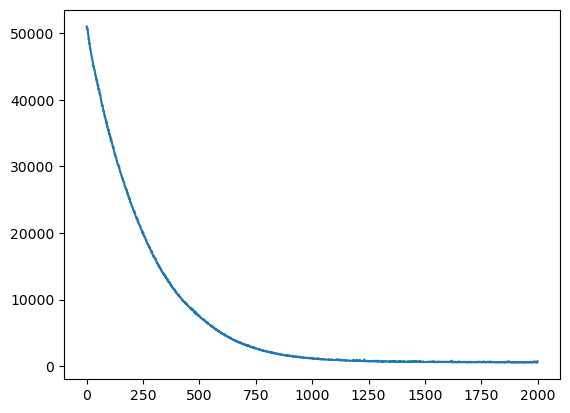

In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(losses)

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

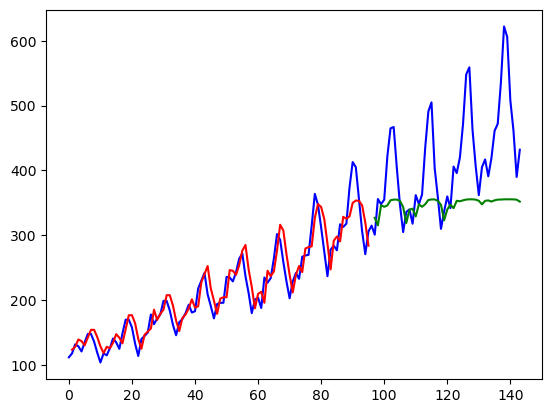

In [54]:
def plot_predicts(timeseries=passengers_qty):
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      y_pred = model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim

# модель
model = AirModel(hidden_size=100, num_layers=1)

# optimizer + loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

losses = []
num_epochs = 2000

for epoch in range(num_epochs):
    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:
        # прямий прохід
        y_pred = model(X_batch)

        # loss
        loss = loss_fn(y_pred, y_batch)

        # backward + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    # валідація кожні 100 епох
    if epoch % 100 == 0:
        model.eval()

        with torch.no_grad():
            train_pred = model(X_train)
            test_pred = model(X_test)

            train_rmse = torch.sqrt(loss_fn(train_pred, y_train))
            test_rmse = torch.sqrt(loss_fn(test_pred, y_test))

        print(
            f"Epoch {epoch}: "
            f"train RMSE {train_rmse.item():.4f}, "
            f"test RMSE {test_rmse.item():.4f}"
        )

Epoch 0: train RMSE 225.7958, test RMSE 422.2106
Epoch 100: train RMSE 145.7946, test RMSE 336.9969
Epoch 200: train RMSE 97.0513, test RMSE 277.7327
Epoch 300: train RMSE 67.6212, test RMSE 233.3898
Epoch 400: train RMSE 48.0950, test RMSE 196.6392
Epoch 500: train RMSE 36.4158, test RMSE 167.8083
Epoch 600: train RMSE 30.5142, test RMSE 145.2064
Epoch 700: train RMSE 27.4309, test RMSE 128.2691
Epoch 800: train RMSE 25.0793, test RMSE 117.1753
Epoch 900: train RMSE 24.0621, test RMSE 108.5759
Epoch 1000: train RMSE 25.7926, test RMSE 104.2894
Epoch 1100: train RMSE 25.4981, test RMSE 101.3803
Epoch 1200: train RMSE 23.9394, test RMSE 97.1178
Epoch 1300: train RMSE 25.6946, test RMSE 96.4029
Epoch 1400: train RMSE 23.5798, test RMSE 93.7241
Epoch 1500: train RMSE 26.5553, test RMSE 90.4456
Epoch 1600: train RMSE 22.9716, test RMSE 89.5717
Epoch 1700: train RMSE 24.1711, test RMSE 89.3315
Epoch 1800: train RMSE 23.0719, test RMSE 87.7740
Epoch 1900: train RMSE 23.8100, test RMSE 90.049

Модель з hidden_size=100 показала кращий результат, ніж модель з hidden_size=50.
У неї менша похибка як на тренувальній вибірці, так і на тестовій: train RMSE зменшився з 24.90 до 23.81, а test RMSE - зі 103.56 до 90.05.

Це означає, що збільшення кількості прихованих нейронів дозволило моделі краще наблизити залежності в часовому ряді. Водночас test RMSE все ще значно більший за train RMSE, тому модель гірше узагальнює прогноз на нових даних. Це може бути ознакою перенавчання або того, що тестова частина ряду має інший масштаб/тренд, який модель погано передбачає.